# 상추 생장량 예측 & 환경 제어

전날 재배 환경으로 다음날 생장량을 예측하고, Optuna로 생장을 높이는 환경 조건을 탐색합니다.


원본 엑셀 없음 → data/lettuce_processed 의 기존 CSV 사용
병합 일수: 30
최고 모델: RandomForest (CV tuned)
학습 샘플: 27일 (전날 환경 → 다음날 생장)

=== 모델 비교 (LOO CV, MAE 순) ===
                      model    MAE_g   RMSE_g        R2  n_samples
    RandomForest (CV tuned) 1.540240 2.652602  0.148350         27
Ridge + lag1 생장량 (CV tuned) 1.584662 2.532447  0.251739         26
GradientBoosting (CV tuned) 1.597074 2.779892  0.064653         27
      ElasticNet (CV tuned) 1.621030 2.532758  0.223567         27
           Ridge (CV tuned) 1.653741 2.545185  0.215928         27
         Ridge (alpha=10.0) 1.670251 2.569001  0.201186         27
           Baseline (평균 예측) 2.161210 2.874362  0.000000         27
  SARIMAX(1,0,0)+환경3종 (LOO) 2.257385 4.841349 -1.836938         27
     ARIMA(1,0,1) 생장만 (LOO) 2.577491 3.268066 -0.292703         27

=== 예측 정확도 (Leave-One-Out) ===
  MAE  : 1.54 g/일
  RMSE : 2.65 g/일
  R²   : 0.148
  MAPE : 39.9%


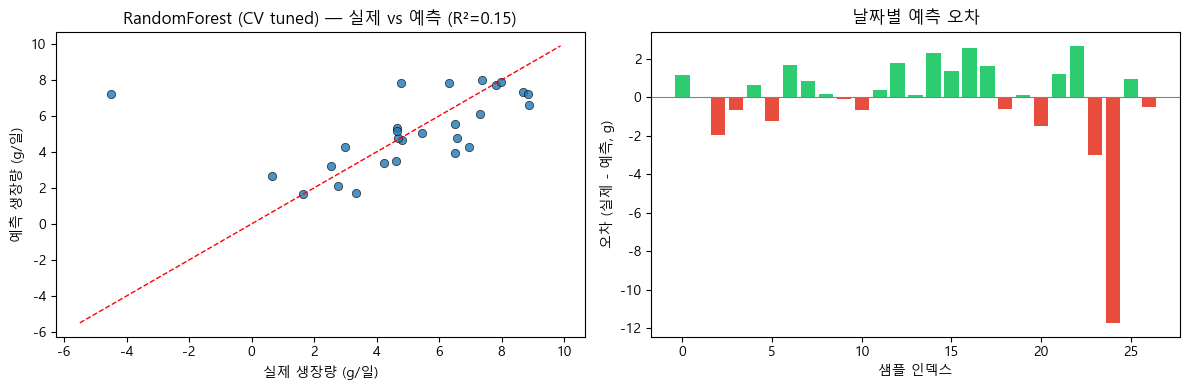

,md,DAT,biomass_delta_g_mean
25,03-18,26.0,6.944444
26,03-19,27.0,4.788889
27,03-20,28.0,-4.494444
28,03-21,29.0,6.511111
29,03-22,30.0,4.638889


In [1]:
# 데이터 로드 및 모델 학습
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FARMETRY = ROOT
SCRIPTS = FARMETRY / "scripts"
OUT = FARMETRY / "data" / "lettuce_processed"
sys.path.insert(0, str(SCRIPTS))

import importlib
import lettuce_growth_env_analysis as lgea
import lettuce_growth_model as lgm
import lettuce_growth_model_compare as lgc

importlib.reload(lgm)
importlib.reload(lgc)
importlib.reload(lgea)

from lettuce_growth_env_analysis import main as rebuild_data
from lettuce_growth_model_compare import train_best_model_bundle

# 원본 엑셀이 있으면 CSV 재생성, 없으면 저장소에 포함된 CSV 사용
try:
    rebuild_data()
except FileNotFoundError:
    print("원본 엑셀 없음 → data/lettuce_processed 의 기존 CSV 사용")
best = train_best_model_bundle()

merged = best["merged"]
bundle = best["bundle"]
lag_df = best["lag_df"]
summary = best["summary"]
best_model = best["best_model"]

metrics = bundle.metrics
cv = bundle.cv_predictions

print(f"병합 일수: {len(merged)}")
print(f"최고 모델: {best_model}")
print(f"학습 샘플: {metrics['n_samples']}일 (전날 환경 → 다음날 생장)\n")

print("=== 모델 비교 (LOO CV, MAE 순) ===")
print(summary[["model", "MAE_g", "RMSE_g", "R2", "n_samples"]].to_string(index=False))

print("\n=== 예측 정확도 (Leave-One-Out) ===")
print(f"  MAE  : {metrics['MAE_g']:.2f} g/일")
print(f"  RMSE : {metrics['RMSE_g']:.2f} g/일")
print(f"  R²   : {metrics['R2']:.3f}")
print(f"  MAPE : {metrics['MAPE_pct']:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(cv["actual_g"], cv["predicted_g"], alpha=0.8, edgecolors="k", linewidths=0.5)
lim = [cv["actual_g"].min() - 1, cv["actual_g"].max() + 1]
axes[0].plot(lim, lim, "r--", lw=1)
axes[0].set_xlabel("실제 생장량 (g/일)")
axes[0].set_ylabel("예측 생장량 (g/일)")
axes[0].set_title(f"{best_model} — 실제 vs 예측 (R²={metrics['R2']:.2f})")

axes[1].bar(
    range(len(cv)),
    cv["error_g"],
    color=["#e74c3c" if e < 0 else "#2ecc71" for e in cv["error_g"]],
)
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_xlabel("샘플 인덱스")
axes[1].set_ylabel("오차 (실제 - 예측, g)")
axes[1].set_title("날짜별 예측 오차")

plt.tight_layout()
plt.show()

merged[["md", "DAT", "biomass_delta_g_mean"]].tail()

- **탐색**: 습도·기온·수온·EC를 Optuna로 최적화
- **출력**: `current` / `next_control_value` / `bayesian_target` 시나리오별 예상 g/주/일




Optuna 환경 최적화 - 예상 일일 생장 (18주 평균, g/주/일)
시나리오: 03-22 (DAT 30.0) | 모델: RandomForest (CV tuned)
탐색: optuna (150 trials) | 최대 예측 생장: 4.207 g/일

[환경 조정 권고]
   variable  current_value  next_control_value  bayesian_target advice
   습도 최저(%)         46.453              43.453           37.227 낮추는 방향
  기온 최저(°C)         18.849              18.924           18.924 높이는 방향
  수온 최저(°C)         17.942              18.388           18.388 높이는 방향
EC 평균(dS/m)          2.205               2.245            2.245 높이는 방향

[조정 요약]
  습도 최저(%): 현재 46.453% → 다음 제어 43.453% (-3.000%), 장기 목표 37.227% (-9.226%)
  기온 최저(°C): 현재 18.849°C → 다음 제어 18.924°C (+0.075°C), 장기 목표 18.924°C (+0.075°C)
  수온 최저(°C): 현재 17.942°C → 다음 제어 18.388°C (+0.446°C), 장기 목표 18.388°C (+0.446°C)
  EC 평균(dS/m): 현재 2.205dS/m → 다음 제어 2.245dS/m (+0.040dS/m), 장기 목표 2.245dS/m (+0.040dS/m)

[시나리오별 예상 생장]
           scenario  pred_growth_g_per_day  growth_increase_g  growth_increase_%
current_environment                  3.994              0.000   

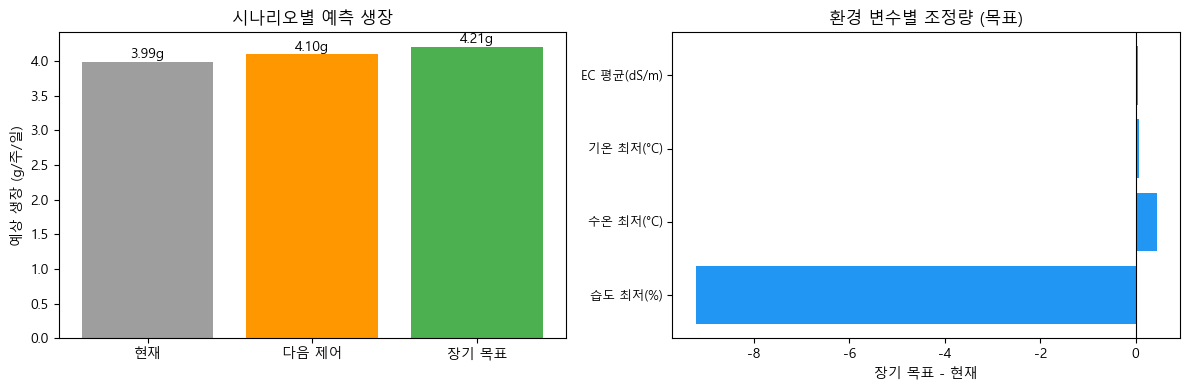

,variable,current_value,next_control_value,bayesian_target,advice
0,습도 최저(%),46.453,43.453,37.227,낮추는 방향
1,기온 최저(°C),18.849,18.924,18.924,높이는 방향
2,수온 최저(°C),17.942,18.388,18.388,높이는 방향
3,EC 평균(dS/m),2.205,2.245,2.245,높이는 방향


In [2]:
# Optuna 환경 제어
import importlib
import lettuce_growth_env_optuna as lgo

importlib.reload(lgo)
from lettuce_growth_env_optuna import run_env_control_optuna

N_TRIALS = 150  # 늘리면 탐색 정밀도 ↑ (시간 ↑)

optuna_result = run_env_control_optuna(
    bundle=bundle,
    lag_df=lag_df,
    merged=merged,
    n_trials=N_TRIALS,
)

ctrl = optuna_result["control_df"]
imp = optuna_result["improvement_df"]

print(f"\n저장: {OUT / 'env_control_optuna.csv'}")
print(f"저장: {OUT / 'env_control_improvement.csv'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
labels = ["현재", "다음 제어", "장기 목표"]
vals = [
    optuna_result["current_pred_g"],
    optuna_result["next_pred_g"],
    optuna_result["target_pred_g"],
]
colors = ["#9e9e9e", "#ff9800", "#4caf50"]
ax.bar(labels, vals, color=colors)
ax.set_ylabel("예상 생장 (g/주/일)")
ax.set_title("시나리오별 예측 생장")
for i, v in enumerate(vals):
    ax.text(i, v + 0.05, f"{v:.2f}g", ha="center", fontsize=10)

ax = axes[1]
show_ctrl = ctrl.sort_values("target_adjustment", key=abs, ascending=False).head(6)
y_pos = range(len(show_ctrl))
ax.barh(list(y_pos), show_ctrl["target_adjustment"], color="#2196f3")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(show_ctrl["variable"], fontsize=9)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("장기 목표 - 현재")
ax.set_title("환경 변수별 조정량 (목표)")
plt.tight_layout()
plt.show()

ctrl[["variable", "current_value", "next_control_value", "bayesian_target", "advice"]]

아래 `SCENARIOS` 목록을 수정한 뒤 실행하세요.


=== 관측일별 환경·실제 생장 ===
   md  DAT  AirHum_pct_min  AirTemp_C_min  WaterTemp_C_min  EC_dS_m_mean  biomass_delta_g_mean
03-13 21.0       34.767719      18.305626        18.094500      2.358899              7.983333
03-14 22.0       33.411557      18.815358        18.323199      2.520363              6.305556
03-15 23.0       34.666706      24.071073        21.312945      2.288838              5.900000
03-16 24.0       35.244817      18.346539        18.306179      2.201251              6.400000
03-17 25.0       41.974561      17.951493        18.047744      1.112933              7.316667
03-18 26.0       44.698557      18.675961        18.484441      1.264951              6.944444
03-19 27.0       45.077986      18.351692        18.148828      2.173938              4.788889
03-20 28.0       39.047029      18.052222        17.823503      2.218343             -4.494444
03-21 29.0       40.431570      18.993564        18.653107      2.155026              6.511111
03-22 30.0       46.453378  

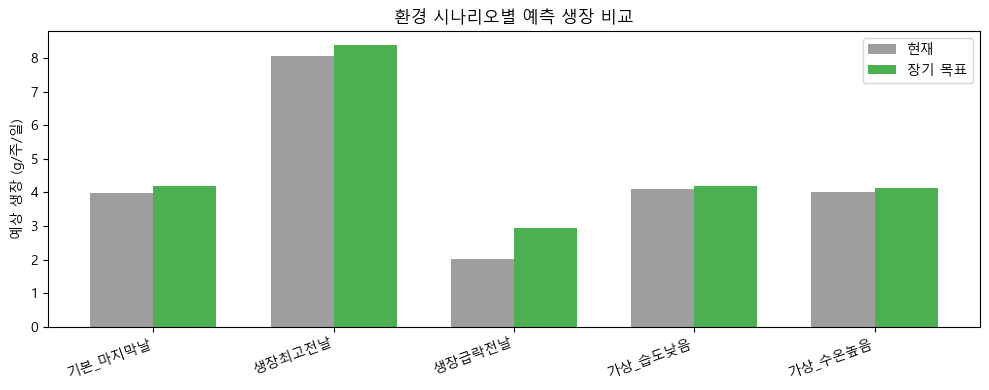


Optuna 환경 최적화 - 예상 일일 생장 (18주 평균, g/주/일)
시나리오: 가상_습도낮음_상세 | 모델: RandomForest (CV tuned)
  ※ 수동 환경 변경: {'AirHum_pct_min': 30, 'WaterTemp_C_min': 19}
탐색: optuna (100 trials) | 최대 예측 생장: 4.189 g/일

[환경 조정 권고]
   variable  current_value  next_control_value  bayesian_target advice
   습도 최저(%)         30.000              33.000           35.833 높이는 방향
  기온 최저(°C)         18.849              18.639           18.639 낮추는 방향
  수온 최저(°C)         19.000              18.500           18.396 낮추는 방향
EC 평균(dS/m)          2.205               2.243            2.243 높이는 방향

[조정 요약]
  습도 최저(%): 현재 30.0% → 다음 제어 33.0% (+3.000%), 장기 목표 35.833% (+5.833%)
  기온 최저(°C): 현재 18.849°C → 다음 제어 18.639°C (-0.210°C), 장기 목표 18.639°C (-0.210°C)
  수온 최저(°C): 현재 19.0°C → 다음 제어 18.5°C (-0.500°C), 장기 목표 18.396°C (-0.604°C)
  EC 평균(dS/m): 현재 2.205dS/m → 다음 제어 2.243dS/m (+0.038dS/m), 장기 목표 2.243dS/m (+0.038dS/m)

[시나리오별 예상 생장]
           scenario  pred_growth_g_per_day  growth_increase_g  growth_increase_%
current_environmen

,feature,variable,unit,current_value,bayesian_target,next_control_value,difference,direction,advice,target_adjustment,next_adjustment,target_adjustment_%,next_adjustment_%,adjustment_summary
0,AirHum_pct_min,습도 최저(%),%,30.000,35.833,33.000,5.833,increase,높이는 방향,5.833,3.000,19.44,10.00,"습도 최저(%): 현재 30.0% → 다음 제어 33.0% (+3.000%), 장기..."
1,AirTemp_C_min,기온 최저(°C),°C,18.849,18.639,18.639,-0.210,decrease,낮추는 방향,-0.210,-0.210,-1.11,-1.11,기온 최저(°C): 현재 18.849°C → 다음 제어 18.639°C (-0.21...
2,WaterTemp_C_min,수온 최저(°C),°C,19.000,18.396,18.500,-0.604,decrease,낮추는 방향,-0.604,-0.500,-3.18,-2.63,수온 최저(°C): 현재 19.0°C → 다음 제어 18.5°C (-0.500°C)...
3,EC_dS_m_mean,EC 평균(dS/m),dS/m,2.205,2.243,2.243,0.038,increase,높이는 방향,0.038,0.038,1.72,1.72,EC 평균(dS/m): 현재 2.205dS/m → 다음 제어 2.243dS/m (+...


In [3]:
# 환경 시나리오 비교
import importlib
import lettuce_growth_env_optuna as lgo

importlib.reload(lgo)
from lettuce_growth_env_optuna import run_env_control_optuna, run_env_scenarios

# 기준일 목록 확인
print("=== 관측일별 환경·실제 생장 ===")
show_cols = ["md", "DAT", "AirHum_pct_min", "AirTemp_C_min", "WaterTemp_C_min", "EC_dS_m_mean", "biomass_delta_g_mean"]
print(merged[show_cols].tail(10).to_string(index=False))

# 비교할 시나리오 (name / base_md / env_override 조합)
SCENARIOS = [
    {"name": "기본_마지막날", "base_md": "03-22"},
    {"name": "생장최고전날", "base_md": "03-10"},
    {"name": "생장급락전날", "base_md": "03-19"},
    {
        "name": "가상_습도낮음",
        "base_md": "03-22",
        "env_override": {"AirHum_pct_min": 30, "WaterTemp_C_min": 19},
    },
    {
        "name": "가상_수온높음",
        "base_md": "03-22",
        "env_override": {"WaterTemp_C_min": 20.5, "EC_dS_m_mean": 2.4},
    },
]

N_TRIALS_SCENARIO = 80

scenario_summary = run_env_scenarios(
    SCENARIOS,
    bundle=bundle,
    lag_df=lag_df,
    merged=merged,
    n_trials=N_TRIALS_SCENARIO,
    verbose_each=False,
)

print("\n=== 시나리오별 Optuna 결과 요약 ===")
print(scenario_summary.to_string(index=False))
print(f"\n저장: {OUT / 'env_scenario_comparison.csv'}")

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(scenario_summary))
w = 0.35
ax.bar([i - w / 2 for i in x], scenario_summary["현재 예측(g/일)"], width=w, label="현재", color="#9e9e9e")
ax.bar([i + w / 2 for i in x], scenario_summary["장기 목표(g/일)"], width=w, label="장기 목표", color="#4caf50")
ax.set_xticks(list(x))
ax.set_xticklabels(scenario_summary["시나리오"], rotation=20, ha="right")
ax.set_ylabel("예상 생장 (g/주/일)")
ax.set_title("환경 시나리오별 예측 생장 비교")
ax.legend()
plt.tight_layout()
plt.show()

detail = run_env_control_optuna(
    bundle=bundle,
    lag_df=lag_df,
    merged=merged,
    base_md="03-22",
    env_override={"AirHum_pct_min": 30, "WaterTemp_C_min": 19},
    scenario_name="가상_습도낮음_상세",
    n_trials=100,
)
detail["control_df"]